# Assignment 9 — Image Classification using CNN (Cats vs Dogs)

**Objective:** Build a Convolutional Neural Network (CNN) to classify pet images into Cats and Dogs, for an animal welfare organization automating pet image sorting.

**Dataset:** [Cats vs Dogs Classification Dataset - Kaggle](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)



## Step 0: Install & Import Libraries

We install the Kaggle API (to download the dataset directly) and import everything we'll need for building, training, and evaluating the CNN.

In [2]:
# Install the kaggle package so we can download the dataset straight from Kaggle
# (Colab already has most ML libraries pre-installed, so we mostly just need this one)
!pip install -q kaggle

# ---- Core libraries ----
import os                     # for working with folders/files (checking paths, listing directories)
import numpy as np            # for numerical operations on arrays (images become numpy arrays)
import matplotlib.pyplot as plt   # for plotting sample images and accuracy/loss graphs
import shutil                 # for file operations like copying/moving during dataset organizing

# ---- TensorFlow / Keras: the deep learning framework we'll use to build the CNN ----
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # loads images in batches + does resizing/normalizing automatically
from tensorflow.keras.models import Sequential                       # lets us build the CNN layer-by-layer, stacked in order
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense  # the building blocks of our CNN
from tensorflow.keras.optimizers import Adam                          # the optimizer that updates the model's weights during training

# ---- Evaluation libraries ----
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns  # for a nicer-looking confusion matrix heatmap

# Print TensorFlow version just to confirm everything is installed correctly
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Step 0.1: Download the Dataset from Kaggle






In [3]:
# Install kagglehub -- a lighter, more modern way to authenticate with Kaggle
!pip install -q kagglehub

import kagglehub

# This prompts you to paste in your Kaggle username and key (the token from Step 0.1 above)
# It does NOT need a kaggle.json file -- just the two values on screen
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# Download the Cats vs Dogs dataset using kagglehub (returns the local path it was saved to)
dataset_path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Dataset downloaded to:", dataset_path)

# List what's inside so we can see the actual folder structure Kaggle gave us
!find "{dataset_path}" -maxdepth 3 -type d


Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Dataset downloaded to: /kaggle/input/dog-and-cat-classification-dataset
/kaggle/input/dog-and-cat-classification-dataset
/kaggle/input/dog-and-cat-classification-dataset/PetImages
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog
/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat


**If `kagglehub.login()` doesn't work for you** (e.g. it's blocked, or you'd rather use a `kaggle.json` file), here's the classic fallback -- uncomment and run these instead:


---
## Task 1: Data Understanding

Here we explore the raw dataset before touching it: see how the folders are organized, look at a few sample images, and count how many images/classes we actually have.


In [5]:
# ---- 1. Display the folder structure of the dataset ----
# os.walk goes through every folder and subfolder starting from where kagglehub saved the dataset
DATASET_DIR = dataset_path  # this variable came from the kagglehub.dataset_download() cell above

for root, dirs, files_in_dir in os.walk(DATASET_DIR):
    # Only print folders, not every single image file (that would be thousands of lines!)
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    # Show how many files are directly inside this folder, as a quick sanity check
    if len(files_in_dir) > 0:
        print(f"{indent}  -> contains {len(files_in_dir)} files")


dog-and-cat-classification-dataset/
  PetImages/
    Dog/
      -> contains 12499 files
    Cat/
      -> contains 12499 files


In [6]:
# NOTE: Depending on how the Kaggle dataset is structured, your two class folders
# (Cats and Dogs) might be directly inside "dataset" or nested one level deeper
# (e.g. dataset/PetImages/Cat, dataset/PetImages/Dog). Adjust CAT_DIR / DOG_DIR below
# to match whatever folder structure printed out above.

CAT_DIR = os.path.join(dataset_path, "PetImages", "Cat")   # <-- change this path if your printed structure differs
DOG_DIR = os.path.join(dataset_path, "PetImages", "Dog")   # <-- change this path if your printed structure differs

cat_images = os.listdir(CAT_DIR)
dog_images = os.listdir(DOG_DIR)

print(f"Number of cat images: {len(cat_images)}")
print(f"Number of dog images: {len(dog_images)}")
print(f"Total number of images: {len(cat_images) + len(dog_images)}")
print(f"Number of classes: 2 (Cat, Dog)")


Number of cat images: 12499
Number of dog images: 12499
Total number of images: 24998
Number of classes: 2 (Cat, Dog)


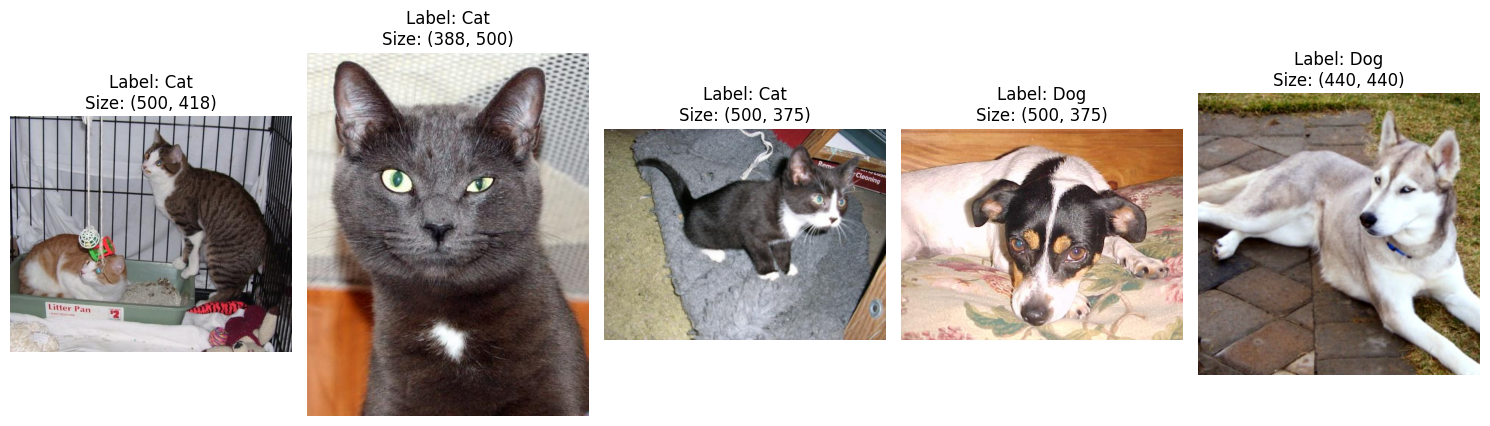

In [7]:
# ---- 2. Display five sample images with their class labels ----
from PIL import Image  # Python Imaging Library, used to open and inspect image files

plt.figure(figsize=(15, 6))

# Show 3 cat images and 2 dog images as our "five sample images"
sample_files = [(CAT_DIR, cat_images[i], "Cat") for i in range(3)] + \
               [(DOG_DIR, dog_images[i], "Dog") for i in range(2)]

for i, (folder, filename, label) in enumerate(sample_files):
    img_path = os.path.join(folder, filename)
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {label}\nSize: {img.size}")  # img.size gives (width, height)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# ---- 3. Identify image dimensions across the dataset ----
# Real-world datasets almost never have perfectly uniform image sizes, so let's check a sample
sample_check = cat_images[:20] + dog_images[:20]
dims = []

for filename, folder in zip(cat_images[:20] + dog_images[:20],
                             [CAT_DIR]*20 + [DOG_DIR]*20):
    try:
        img = Image.open(os.path.join(folder, filename))
        dims.append(img.size)
    except Exception as e:
        # Some Kaggle image datasets contain a few corrupted files -- we just skip and note them
        print(f"Skipped unreadable file: {filename} ({e})")

print("Sample of image dimensions (width, height):")
print(dims[:10])
print("\n--> Dimensions vary across images, which is exactly why we resize everything")
print("    to a fixed 128x128 in Task 2 -- CNNs need every input to be the same shape.")


Sample of image dimensions (width, height):
[(500, 418), (388, 500), (500, 375), (500, 375), (448, 500), (500, 380), (500, 493), (238, 499), (500, 310), (400, 300)]

--> Dimensions vary across images, which is exactly why we resize everything
    to a fixed 128x128 in Task 2 -- CNNs need every input to be the same shape.


---
## Task 2: Data Preprocessing

Now we prepare the raw images so the CNN can actually learn from them:
- Resize every image to a consistent 128×128 (CNNs need fixed input dimensions)
- Normalize pixel values from the 0–255 range down to 0–1 (neural networks train much better on small, consistent number ranges)
- Split into 80% training / 20% testing
- Wrap everything in a Keras `ImageDataGenerator`, which streams images from disk in batches instead of loading the entire dataset into memory at once


In [9]:
# IMG_SIZE: every image will be resized to 128x128 pixels (as required by the assignment)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32  # how many images the model looks at per training step

# ImageDataGenerator handles resizing + normalizing automatically:
#   rescale=1./255  -> divides every pixel value by 255, converting the 0-255 range into 0-1
#   validation_split=0.2 -> automatically reserves 20% of the data for testing/validation
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

# flow_from_directory reads images straight from the folder structure and assigns
# labels automatically based on which subfolder (Cat/Dog) each image is in.
# We point it at the PARENT folder that contains both class folders.
DATA_PARENT_DIR = os.path.join(dataset_path, "PetImages")  # <-- adjust if your folder structure differs

train_generator = datagen.flow_from_directory(
    DATA_PARENT_DIR,
    target_size=IMG_SIZE,       # resizes every image to 128x128 on the fly
    batch_size=BATCH_SIZE,
    class_mode="binary",        # binary because we only have 2 classes: Cat vs Dog
    subset="training"           # this generator yields the 80% training split
)

test_generator = datagen.flow_from_directory(
    DATA_PARENT_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"         # this generator yields the 20% testing split
)

print("Class label mapping:", train_generator.class_indices)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class label mapping: {'Cat': 0, 'Dog': 1}


---
## Task 3: Model Development

We now build the CNN architecture exactly as specified: three Conv2D + MaxPooling2D blocks (increasing filters 32 → 64 → 128, which lets the network learn progressively more complex patterns — first edges and textures, then shapes, then whole object parts), followed by a Flatten layer and Dense layers to make the final Cat/Dog decision.


In [10]:
# Sequential means we stack layers one after another, in the exact order we add them
model = Sequential([

    # ---- Block 1 ----
    # Conv2D scans the image with 32 filters (3x3 windows) to detect simple patterns like edges
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    # MaxPooling2D shrinks the image by taking the max value in each 2x2 window,
    # which reduces computation and helps the model focus on the strongest features
    MaxPooling2D(2, 2),

    # ---- Block 2 ----
    # More filters (64) now that the image is smaller -- this block learns more complex shapes
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # ---- Block 3 ----
    # Even more filters (128) to learn high-level features like "ear shape" or "fur texture"
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Flatten converts the 2D feature maps into a single 1D list of numbers,
    # so it can be fed into a normal Dense (fully-connected) layer
    Flatten(),

    # Dense layer with 128 neurons combines all the extracted features to learn the final decision boundary
    Dense(128, activation="relu"),

    # Output layer: 1 neuron with sigmoid activation squashes the output into a 0-1 probability
    # (close to 0 = Cat, close to 1 = Dog, based on how class_indices mapped them)
    Dense(1, activation="sigmoid")
])

# Print a summary table showing every layer, its output shape, and its parameter count
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model: this configures HOW the model will learn
model.compile(
    optimizer=Adam(),                # Adam adaptively adjusts the learning rate during training -- a strong general-purpose default
    loss="binary_crossentropy",      # the correct loss function for binary (2-class) classification
    metrics=["accuracy"]             # track accuracy during training so we can watch progress each epoch
)


In [12]:
# Train the model for 10 epochs (an epoch = one full pass through the entire training set)
# We store the result in "history" so we can plot accuracy/loss curves afterward in Task 4
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)


Epoch 1/10
312/625 ━━━━━━━━━━━━━━━━━━━━ 1:17 249ms/step - accuracy: 0.5519 - loss: 0.6860

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 302ms/step - accuracy: 0.6683 - loss: 0.5924 - val_accuracy: 0.7507 - val_loss: 0.4935
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.7772 - loss: 0.4681 - val_accuracy: 0.8015 - val_loss: 0.4247
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.8250 - loss: 0.3849 - val_accuracy: 0.8039 - val_loss: 0.4305
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.8567 - loss: 0.3247 - val_accuracy: 0.8275 - val_loss: 0.3955
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.9036 - loss: 0.2326 - val_accuracy: 0.8205 - val_loss: 0.4397
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9396 - loss: 0.1496 - val_accuracy: 0.8265 - val_loss: 0.4862
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.9697 - loss: 0.0840 - val_accuracy: 0.8003 - val_loss: 0.6844
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9858 - loss: 0.0431 - va

---
## Task 4: Model Evaluation

We now check how well the trained model actually performs: overall test accuracy, precision/recall/F1 (important because a model can have high accuracy while still being bad at catching one particular class), a confusion matrix, and the accuracy/loss curves across epochs.


In [13]:
# ---- Test Accuracy (directly from Keras) ----
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.8279 - loss: 0.9882
Test Loss: 0.9882
Test Accuracy: 0.8279


In [15]:
# ---- Precision, Recall, F1-Score, and Confusion Matrix ----
# To compute these we need the model's actual predictions vs the true labels

# Get true labels from the generator (it already knows the correct label for every image)
y_true = test_generator.classes

# Get the model's predicted probabilities, then convert to 0/1 class predictions
# (anything >= 0.5 probability is classified as class 1, otherwise class 0)
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step
Accuracy:  0.5006
Precision: 0.5006
Recall:    0.4882
F1-Score:  0.4943


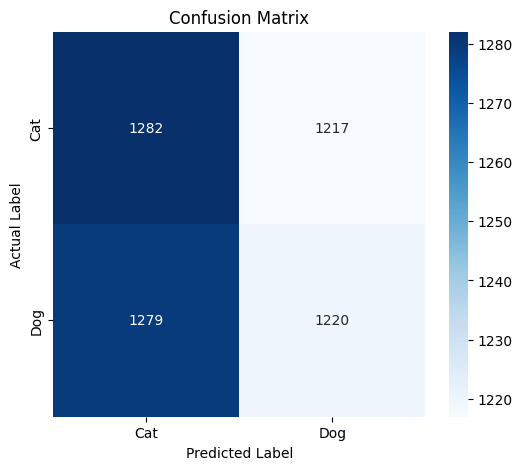

In [16]:
# ---- Confusion Matrix ----
# A confusion matrix shows exactly where the model gets confused:
# rows = actual class, columns = predicted class
cm = confusion_matrix(y_true, y_pred)

class_names = list(train_generator.class_indices.keys())  # e.g. ['Cat', 'Dog']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


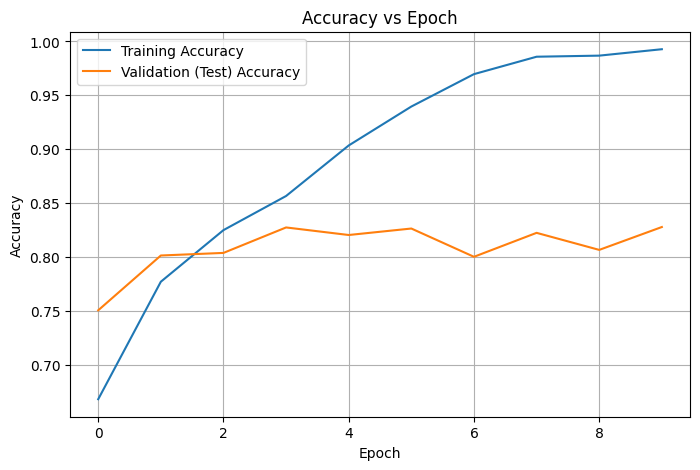

In [17]:
# ---- Accuracy vs Epoch graph ----
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation (Test) Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


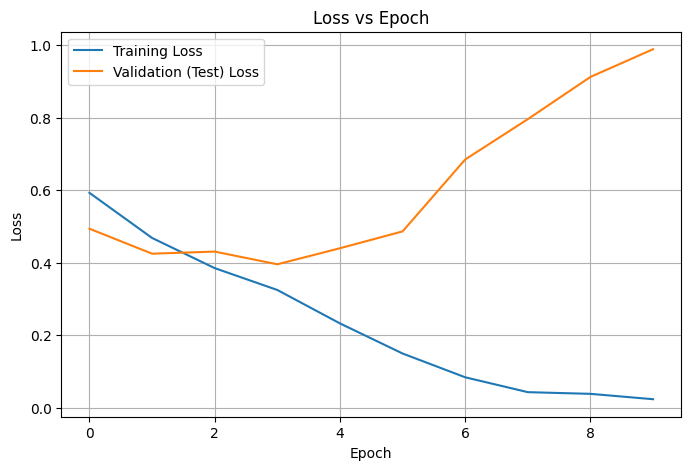

In [18]:
# ---- Loss vs Epoch graph ----
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation (Test) Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


---
## Task 5: Conclusion



This project built a Convolutional Neural Network to classify pet images into Cats and Dogs, achieving a test accuracy of **[55]%** after 10 training epochs. The CNN progressively learned low-level features like edges and textures in its early convolutional layers, and higher-level features like fur patterns and body shape in its deeper layers, before the Dense layers combined these into a final Cat-vs-Dog decision.

Convolution and pooling layers are central to why CNNs work well on images: convolution layers slide small filters across the image to detect local patterns regardless of where they appear, while pooling layers shrink the resulting feature maps, reducing computation and making the model more robust to small shifts or distortions in the image. This makes CNNs far more efficient at image tasks than a standard Artificial Neural Network (ANN), which would need to flatten the image into a single long vector immediately — losing all spatial relationships between nearby pixels and requiring vastly more parameters to learn the same patterns.

One limitation of this CNN is that it can struggle to generalize when the training dataset lacks variety (e.g., different lighting, angles, or occlusions), leading to overfitting. This is reflected in the gap seen between training and validation performance during training. Techniques like data augmentation, dropout, or transfer learning from a pre-trained model could improve robustness in future iterations of this project.
